In [1]:
%matplotlib widget

In [2]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
import pygimli as pg
from sklearn.metrics import root_mean_squared_error
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

from FDEM1D import LCModelling #FDEM1DModelling, LCModelling, FDEM1D

from matplotlib.colors import LogNorm


L = LogNorm(vmin=0.001, vmax=1)
popts = {'norm': L}

In [3]:
def FDEM1D(sgm, thk, height=0.3, ):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]
                
    norm : normalize values with respect to offset

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    #height = 0

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    HOP = []
    HIP = []
    POP = []
    PIP = []
    VOP = []
    VIP = []
    
    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp()# * norm
        ip = (H_Hs/H_Hp).real.amp()# * norm
        HOP.append(op) 
        HIP.append(ip)

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp()# * norm
        ip = (P_Hs/P_Hp).real.amp()# * norm
        POP.append(op)
        PIP.append(ip)
        
    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp()# * norm
        ip = (V_Hs/V_Hp).real.amp()# * norm
        VOP.append(op)
        VIP.append(ip)

    return np.array([HOP, POP, VOP, HIP, PIP, VIP]).ravel() 

class FDEM1DModelling(pg.frameworks.Modelling):
    
    def __init__(self, nlay=2, height = 0.3):
        self.nlay = nlay
        self.height = height
        mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(mesh)
        #print('im using this one')
                   
    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
        resp = FDEM1D(np.asarray(par)[self.nlay-1:self.nlay*2-1],   # sigma
                      np.asarray(par)[:self.nlay-1],                  # thickness
                      height = self.height)
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
    
    def createJacobian(self, par, dx=1e-4):
        """ compute Jacobian for a 1D model """
        resp = self.response(par)
        n_rows = len(resp) # number of data values in data vector
        n_cols = len(par) # number of model parameters
        J = self.jacobian() # we define first this as the jacobian
        J.resize(n_rows, n_cols)
        Jt = np.zeros((n_cols, n_rows))
        for j in range(n_cols):
            mod_plus_dx = par.copy()
            mod_plus_dx[j] += dx
            Jt[j,:] = (self.response(mod_plus_dx) - resp)/dx # J.T in col j
        for i in range(n_rows):
            J[i] = Jt[:,i]
        #print(self.jacobian())
        #print(J)
        #print(Jt)
        
    def drawModel(self, ax, model):
        pg.viewer.mpl.drawModel1D(ax = ax,
                                  model = model,
                                  plot = 'semilogx',
                                  xlabel = 'Electrical conductivity (S/m)',
                                  )
        ax.set_ylabel('Depth in (m)')



In [4]:
model_true = np.load('model_Sinu.npy')[:-3]

model_true[:,1] = model_true[:,1]*1000
model_true[:,2] = model_true[:,2]*1000

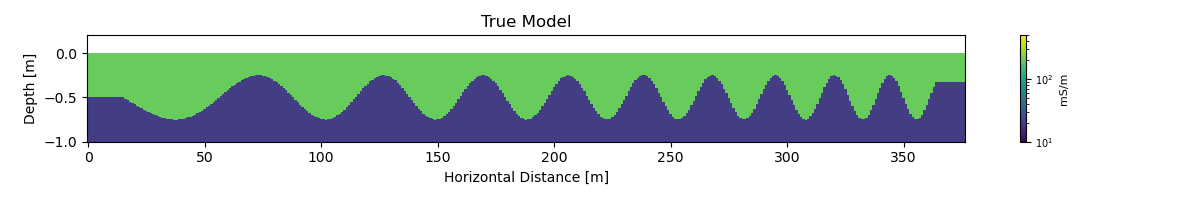

In [5]:
fig, ax = plt.subplots(figsize=(12,2))

inputs= {'label' : 'mS/m'}

showStitchedModels(model_true, zMax=2, ax=ax, cMin=10, cMax=500, **inputs)
ax.set_ylim([-1, 0.2])
ax.set_title('True Model')
ax.set_xlabel('Horizontal Distance [m]')
ax.set_ylabel('Depth [m]')
plt.tight_layout()
plt.savefig('figures/Sinu_true.eps', format='eps')

In [6]:
data_true = np.load('data_3D_Sinusoidal_sorted.npy')
midp_x = np.load('midpx_data_Sinu.npy')

norm = np.array([4, 2, 1, 4, 2, 1, 4, 2, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1])
data_true_norm = data_true[:] # * norm

In [7]:
print(len(model_true))
print(len(data_true))

377
377


In [8]:
i1 = 0
i2 = 377

In [9]:
# Define a start model
model_ini = np.ones_like(model_true[i1:i2])
model_ini[:,0] = model_ini[:,0]*1   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.05 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.05 # initial sigma_2

data_true_norm =  data_true_norm[i1:i2]

In [10]:
# number of layers
nLayers = np.shape(model_true)[1] -1

# number of measurement positions 
npos = len(data_true_norm)

LCI = LCModelling(FDEM1DModelling)

hw = 1
sw = 1

LCI.initJacobian(dataVals=data_true_norm, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data_true_norm, nLay=nLayers)
LCI.normalization(data_true_norm, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data_true_norm, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,2)
transSig = pg.trans.TransLogLU(1/1000, 300/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data_true_norm.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3 

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

model_inv = np.array(model_inv).reshape(np.shape(model_true[i1:i2]))
data_inv = np.array(inv.response)
data_inv = data_inv.reshape(np.shape(data_true_norm))

Inversion is normalized
Jacobian size: 6768 1128 6786


16/11/25 - 16:16:19 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 1128
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f999ebb00e0>


16/11/25 - 16:16:20 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [11]:
model_inv = np.array(model_inv)

In [12]:
model_h_rmse = root_mean_squared_error(model_true[i1:i2,0].ravel(), model_inv[:,0].ravel())
model_s_rmse = root_mean_squared_error(model_true[i1:i2,1:].ravel(), (model_inv[:,1:]*1000).ravel())
data_rmse = root_mean_squared_error(data_true_norm.ravel(), data_inv.ravel())*1000

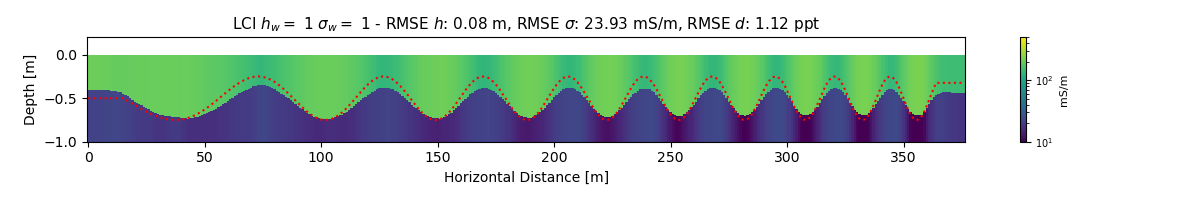

In [13]:
fig, ax = plt.subplots(figsize=(12,2))

model_inv_ = model_inv.copy()
model_inv_[:,1] = model_inv[:,1]*1000
model_inv_[:,2] = model_inv[:,2]*1000

showStitchedModels(model_inv_,  zMax=4, cMin=10, cMax=500, ax=ax, **inputs)
ax.set_title(f'LCI $h_w = $ {hw} $\sigma_w = $ {sw} - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt', fontsize=11)
#ax.set_title(f'PWI - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt', fontsize=11)
ax.set_ylim([-1, 0.2])
ax.plot(-model_true[i1:i2,0], ':r')
ax.set_xlabel('Horizontal Distance [m]')
ax.set_ylabel('Depth [m]')
plt.tight_layout()
plt.savefig('figures/Sinu_inv_LCI.eps', format='eps')

In [45]:
#np.save('data_Sinusoidal_LCI.npy', data_inv)
#np.save('data_Sinusoidal_PWI.npy', data_inv)


# Compare data

In [14]:
plt.style.use('bmh')

In [15]:
data_1D = np.zeros_like(data_true_norm)

for i, m in enumerate(model_true):
    data_1D[i, :] = FDEM1D(m[1:]/1000, m[0], height=0.3)

In [16]:
data_lci = np.load('data_Sinusoidal_LCI.npy')
data_pwi = np.load('data_Sinusoidal_PWI.npy')

In [17]:
# Plot data

def PlotDatas(data_true, data_1D, data_lci, data_pwi, case='', slope=''):

    fig, ax = plt.subplots(12,3, figsize=(12,12), sharex=True, layout='constrained')

    fs1 = 8
    fs2 = 9  

    # column 1
    ax[0,0].plot(data_true[:,0]*1000, 'r')
    ax[0,0].plot(data_1D[:,0]*1000, 'k')
    ax[0,0].plot(data_lci[:,0]*1000, '--b')
    ax[0,0].plot(data_pwi[:,0]*1000, '-.g')
    ax[0,0].set_title('HCP $s=2m$ Quadrature', fontsize=fs2)

    ax[0,1].plot(data_true[:,6]*1000, 'r')
    ax[0,1].plot(data_1D[:,6]*1000, 'k')
    ax[0,1].plot(data_lci[:,6]*1000, '--b')
    ax[0,1].plot(data_pwi[:,6]*1000, '-.g')
    ax[0,1].set_title('VCP $s=2m$ Quadrature', fontsize=fs2)

    ax[0,2].plot(data_true[:,3]*1000, 'r')
    ax[0,2].plot(data_1D[:,3]*1000, 'k')
    ax[0,2].plot(data_lci[:,3]*1000, '--b')
    ax[0,2].plot(data_pwi[:,3]*1000, '-.g')
    ax[0,2].set_title('PRP $s=2.1m$ Quadrature', fontsize=fs2)

    ax[2,0].plot(data_true[:,9]*1000, 'r')
    ax[2,0].plot(data_1D[:,9]*1000, 'k')
    ax[2,0].plot(data_lci[:,9]*1000, '--b')
    ax[2,0].plot(data_pwi[:,9]*1000, '-.g')
    ax[2,0].set_title('HCP $s=2m$ In-Phase', fontsize=fs2)

    ax[2,1].plot(data_true[:,15]*1000, 'r')
    ax[2,1].plot(data_1D[:,15]*1000, 'k')
    ax[2,1].plot(data_lci[:,15]*1000, '--b')
    ax[2,1].plot(data_pwi[:,15]*1000, '-.g')
    ax[2,1].set_title('VCP $s=2m$ In-Phase', fontsize=fs2)

    ax[2,2].plot(data_true[:,12]*1000, 'r')
    ax[2,2].plot(data_1D[:,12]*1000, 'k')
    ax[2,2].plot(data_lci[:,12]*1000, '--b')
    ax[2,2].plot(data_pwi[:,12]*1000, '-.g')
    ax[2,2].set_title('PRP $s=2.1m$ In-Phase', fontsize=fs2)

    #column 2
    ax[1,0].plot(np.abs((data_true[:,0] - data_1D[:,0])/data_true[:,0])*100, 'k')
    ax[1,0].plot(np.abs((data_true[:,0] - data_lci[:,0])/data_true[:,0])*100, '--b')
    ax[1,0].plot(np.abs((data_true[:,0] - data_pwi[:,0])/data_true[:,0])*100, '-.g')
    ax[1,0].set_title('Difference %', fontsize=fs2)

    ax[1,1].plot(np.abs((data_true[:,6] - data_1D[:,6])/data_true[:,6])*100, 'k')
    ax[1,1].plot(np.abs((data_true[:,6] - data_lci[:,6])/data_true[:,6])*100, '--b')
    ax[1,1].plot(np.abs((data_true[:,6] - data_pwi[:,6])/data_true[:,6])*100, '-.g')
    ax[1,1].set_title('Difference %', fontsize=fs2)

    ax[1,2].plot(np.abs((data_true[:,3] - data_1D[:,3])/data_true[:,3])*100, 'k')
    ax[1,2].plot(np.abs((data_true[:,3] - data_lci[:,3])/data_true[:,3])*100, '--b')
    ax[1,2].plot(np.abs((data_true[:,3] - data_pwi[:,3])/data_true[:,3])*100, '-.g')
    ax[1,2].set_title('Difference %', fontsize=fs2)

    ax[3,0].plot(np.abs((data_true[:,9] - data_1D[:,9])/data_true[:,9])*100, 'k')
    ax[3,0].plot(np.abs((data_true[:,9] - data_lci[:,9])/data_true[:,9])*100, '--b')
    ax[3,0].plot(np.abs((data_true[:,9] - data_pwi[:,9])/data_true[:,9])*100, '-.g')
    ax[3,0].set_title('Difference %', fontsize=fs2)

    ax[3,1].plot(np.abs((data_true[:,12] - data_1D[:,12])/data_true[:,12])*100, 'k')
    ax[3,1].plot(np.abs((data_true[:,12] - data_lci[:,12])/data_true[:,12])*100, '--b')
    ax[3,1].plot(np.abs((data_true[:,12] - data_pwi[:,12])/data_true[:,12])*100, '-.g')
    ax[3,1].set_title('Difference %', fontsize=fs2)

    ax[3,2].plot(np.abs((data_true[:,15] - data_1D[:,15])/data_true[:,15])*100, 'k')
    ax[3,2].plot(np.abs((data_true[:,15] - data_lci[:,15])/data_true[:,15])*100, '--b')
    ax[3,2].plot(np.abs((data_true[:,15] - data_pwi[:,15])/data_true[:,15])*100, '-.g')
    ax[3,2].set_title('Difference %', fontsize=fs2)
    
    # column 3
    ax[4,0].plot(data_true[:,1]*1000, 'r')
    ax[4,0].plot(data_1D[:,1]*1000, 'k')
    ax[4,0].plot(data_lci[:,1]*1000, '--b')
    ax[4,0].plot(data_pwi[:,1]*1000, '-.g')
    ax[4,0].set_title('HCP $s=4m$ Quadrature', fontsize=fs2)

    ax[4,1].plot(data_true[:,7]*1000, 'r')
    ax[4,1].plot(data_1D[:,7]*1000, 'k')
    ax[4,1].plot(data_lci[:,7]*1000, '--b')
    ax[4,1].plot(data_pwi[:,7]*1000, '-.g')
    ax[4,1].set_title('VCP $s=4m$ Quadrature', fontsize=fs2)

    ax[4,2].plot(data_true[:,4]*1000, 'r')
    ax[4,2].plot(data_1D[:,4]*1000, 'k')
    ax[4,2].plot(data_lci[:,4]*1000, '--b')
    ax[4,2].plot(data_pwi[:,4]*1000, '-.g')
    ax[4,2].set_title('PRP $s=4.1m$ Quadrature', fontsize=fs2)

    ax[6,0].plot(data_true[:,10]*1000, 'r')
    ax[6,0].plot(data_1D[:,10]*1000, 'k')
    ax[6,0].plot(data_lci[:,10]*1000, '--b')
    ax[6,0].plot(data_pwi[:,10]*1000, '-.g')
    ax[6,0].set_title('HCP $s=4m$ In-Phase', fontsize=fs2)

    ax[6,1].plot(data_true[:,16]*1000, 'r')
    ax[6,1].plot(data_1D[:,16]*1000, 'k')
    ax[6,1].plot(data_lci[:,16]*1000, '--b')
    ax[6,1].plot(data_pwi[:,16]*1000, '-.g')
    ax[6,1].set_title('VCP $s=4m$ In-Phase', fontsize=fs2)

    ax[6,2].plot(data_true[:,13]*1000, 'r')
    ax[6,2].plot(data_1D[:,13]*1000, 'k')
    ax[6,2].plot(data_lci[:,13]*1000, '--b')
    ax[6,2].plot(data_pwi[:,13]*1000, '-.g')
    ax[6,2].set_title('PRP $s=4.1m$ In-Phase', fontsize=fs2)

    #column 4
    ax[5,0].plot(np.abs((data_true[:,1] - data_1D[:,1])/data_true[:,1])*100, 'k')
    ax[5,0].plot(np.abs((data_true[:,1] - data_lci[:,1])/data_true[:,1])*100, '--b')
    ax[5,0].plot(np.abs((data_true[:,1] - data_pwi[:,1])/data_true[:,1])*100, '-.g')
    ax[5,0].set_title('Difference %', fontsize=fs2)

    ax[5,1].plot(np.abs((data_true[:,7] - data_1D[:,7])/data_true[:,7])*100, 'k')
    ax[5,1].plot(np.abs((data_true[:,7] - data_lci[:,7])/data_true[:,7])*100, '--b')
    ax[5,1].plot(np.abs((data_true[:,7] - data_pwi[:,7])/data_true[:,7])*100, '-.g')
    ax[5,1].set_title('Difference %', fontsize=fs2)

    ax[5,2].plot(np.abs((data_true[:,4] - data_1D[:,4])/data_true[:,1])*100, 'k')
    ax[5,2].plot(np.abs((data_true[:,4] - data_lci[:,4])/data_true[:,1])*100, '--b')
    ax[5,2].plot(np.abs((data_true[:,4] - data_pwi[:,4])/data_true[:,1])*100, '-.g')
    ax[5,2].set_title('Difference %', fontsize=fs2)

    ax[7,0].plot(np.abs((data_true[:,10] - data_1D[:,10])/data_true[:,10])*100, 'k')
    ax[7,0].plot(np.abs((data_true[:,10] - data_lci[:,10])/data_true[:,10])*100, '--b')
    ax[7,0].plot(np.abs((data_true[:,10] - data_pwi[:,10])/data_true[:,10])*100, '-.g')
    ax[7,0].set_title('Difference %', fontsize=fs2)

    ax[7,1].plot(np.abs((data_true[:,13] - data_1D[:,13])/data_true[:,13])*100, 'k')
    ax[7,1].plot(np.abs((data_true[:,13] - data_lci[:,13])/data_true[:,13])*100, '--b')
    ax[7,1].plot(np.abs((data_true[:,13] - data_pwi[:,13])/data_true[:,13])*100, '-.g')
    ax[7,1].set_title('Difference %', fontsize=fs2)

    ax[7,2].plot(np.abs((data_true[:,16] - data_1D[:,16])/data_true[:,16])*100, 'k')
    ax[7,2].plot(np.abs((data_true[:,16] - data_lci[:,16])/data_true[:,16])*100, '--b')
    ax[7,2].plot(np.abs((data_true[:,16] - data_pwi[:,16])/data_true[:,16])*100, '-.g')
    ax[7,2].set_title('Difference %', fontsize=fs2)

    # column 5
    ax[8,0].plot(data_true[:,2]*1000, 'r', label='3D')
    ax[8,0].plot(data_1D[:,2]*1000, 'k', label = '1D')
    ax[8,0].plot(data_lci[:,2]*1000, '--b', label='LCI')
    ax[8,0].plot(data_pwi[:,2]*1000, '-.g', label='PWI')
    ax[8,0].set_title('HCP $s=8m$ Quadrature', fontsize=fs2)

    ax[8,1].plot(data_true[:,8]*1000, 'r')
    ax[8,1].plot(data_1D[:,8]*1000, 'k')
    ax[8,1].plot(data_lci[:,8]*1000, '--b')
    ax[8,1].plot(data_pwi[:,8]*1000, '-.g')
    ax[8,1].set_title('VCP $s=8m$ Quadrature', fontsize=fs2)

    ax[8,2].plot(data_true[:,5]*1000, 'r')
    ax[8,2].plot(data_1D[:,5]*1000, 'k')
    ax[8,2].plot(data_lci[:,5]*1000, '--b')
    ax[8,2].plot(data_pwi[:,5]*1000, '-.g')
    ax[8,2].set_title('PRP $s=8.1m$ Quadrature', fontsize=fs2)

    ax[10,0].plot(data_true[:,11]*1000, 'r')
    ax[10,0].plot(data_1D[:,11]*1000, 'k')
    ax[10,0].plot(data_lci[:,11]*1000, '--b')
    ax[10,0].plot(data_pwi[:,11]*1000, '-.g')
    ax[10,0].set_title('HCP $s=8m$ In-Phase', fontsize=fs2)

    ax[10,1].plot(data_true[:,17]*1000, 'r')
    ax[10,1].plot(data_1D[:,17]*1000, 'k')
    ax[10,1].plot(data_lci[:,17]*1000, '--b')
    ax[10,1].plot(data_pwi[:,17]*1000, '-.g')
    ax[10,1].set_title('VCP $s=8m$ In-Phase', fontsize=fs2)

    ax[10,2].plot(data_true[:,14]*1000, 'r')
    ax[10,2].plot(data_1D[:,14]*1000, 'k')
    ax[10,2].plot(data_lci[:,14]*1000, '--b')
    ax[10,2].plot(data_pwi[:,14]*1000, '-.g')
    ax[10,2].set_title('PRP $s=8.1m$ In-Phase', fontsize=fs2)

    #column 6
    x = np.arange(0,40)
    ax[9,0].plot(np.abs((data_true[:,2] - data_1D[:,2])/data_true[:,2])*100, 'k')
    ax[9,0].plot(np.abs((data_true[:,2] - data_lci[:,2])/data_true[:,2])*100, '--b')
    ax[9,0].plot(np.abs((data_true[:,2] - data_pwi[:,2])/data_true[:,2])*100, '-.g')
    ax[9,0].set_title('Difference %', fontsize=fs2)

    ax[9,1].plot(np.abs((data_true[:,8] - data_1D[:,8])/data_true[:,8])*100, 'k')
    ax[9,1].plot(np.abs((data_true[:,8] - data_lci[:,8])/data_true[:,8])*100, '--b')
    ax[9,1].plot(np.abs((data_true[:,8] - data_pwi[:,8])/data_true[:,8])*100, '-.g')
    ax[9,1].set_title('Difference %', fontsize=fs2)

    ax[9,2].plot(np.abs((data_true[:,5] - data_1D[:,5])/data_true[:,5])*100, 'k')
    ax[9,2].plot(np.abs((data_true[:,5] - data_lci[:,5])/data_true[:,5])*100, '--b')
    ax[9,2].plot(np.abs((data_true[:,5] - data_pwi[:,5])/data_true[:,5])*100, '-.g')
    ax[9,2].set_title('Difference %', fontsize=fs2)

    ax[11,0].plot(np.abs((data_true[:,11] - data_1D[:,11])/data_true[:,11])*100, 'k')
    ax[11,0].plot(np.abs((data_true[:,11] - data_lci[:,11])/data_true[:,11])*100, '--b')
    ax[11,0].plot(np.abs((data_true[:,11] - data_pwi[:,11])/data_true[:,11])*100, '-.g')
    ax[11,0].set_title('Difference %', fontsize=fs2)

    ax[11,1].plot(np.abs((data_true[:,14] - data_1D[:,14])/data_true[:,14])*100, 'k')
    ax[11,1].plot(np.abs((data_true[:,14] - data_lci[:,14])/data_true[:,14])*100, '--b')
    ax[11,1].plot(np.abs((data_true[:,14] - data_pwi[:,14])/data_true[:,14])*100, '-.g')
    ax[11,1].set_title('Difference %', fontsize=fs2)

    ax[11,2].plot(np.abs((data_true[:,17] - data_1D[:,17])/data_true[:,17])*100, 'k')
    ax[11,2].plot(np.abs((data_true[:,17] - data_lci[:,17])/data_true[:,17])*100, '--b')
    ax[11,2].plot(np.abs((data_true[:,17] - data_pwi[:,17])/data_true[:,17])*100, '-.g')
    ax[11,2].set_title('Difference %', fontsize=fs2)

    ax[0,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[2,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[4,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[6,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[8,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[10,0].set_ylabel('[ppt]', fontsize=fs1)

    ax[11,0].set_xlabel('Distance [m]', fontsize=fs1)
    ax[11,1].set_xlabel('Distance [m]', fontsize=fs1)
    ax[11,2].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,3].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,4].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,5].set_xlabel('Distance [m]', fontsize=fs1)

    h, l = ax[8,0].get_legend_handles_labels()
    ax[0,2].legend(h, l, bbox_to_anchor=(1.01, 1.01), fontsize=fs1)
    
    for a in ax.ravel():
        a.tick_params(labelsize=fs1)

    #fig.suptitle('Data fit')
    plt.show()

In [28]:
def PlotDatas(data_true, data_1D, data_lci, data_pwi, case='', slope=''):

    fig, ax = plt.subplots(6,6, figsize=(12,6), sharex=True, constrained_layout=True)

    fs1 = 8
    fs2 = 9

    listd = [0, 6, 3, 9, 15, 12]
    listp = [0, 1, 2, 3, 4, 5]
    titles = ['HCP $s=2m$ Quadrature', 'VCP $s=2m$ Quadrature', 'PRP $s=2.1m$ Quadrature', 
              'HCP $s=2m$ In-Phase', 'VCP $s=2m$ In-Phase', 'PRP $s=2.1m$ In-Phase']
    x = np.arange(0,len(data_true))

    for i in range(6):
        ax[i,0].plot(data_true[:,listd[i]]*1000, 'r', label='3D')
        ax[i,0].plot(data_1D[:,listd[i]]*1000, 'k', label='1D')
        ax[i,0].plot(data_lci[:,listd[i]]*1000, '--b', label='LCI')
        ax[i,0].plot(data_pwi[:,listd[i]]*1000, '-.g', label='PWI')
        
        error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
        error1d_std = np.std(error1d)
        ax[i,0].fill_between(x, data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5, label='SD 1D' )

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,0].fill_between(x, data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5, label='SD LCI')

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,0].fill_between(x, data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5, label='SD PWI')
        
        ax[i,0].set_title(titles[i], fontsize=fs2)
    
    #column 2
    styles = ['k', '--b', '-.g']

    for i in range(6):

        error_1D = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
        error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi =  np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
        ax[i,1].plot(error_1D, styles[0])
        ax[i,1].plot(error_lci, styles[1])
        ax[i,1].plot(error_pwi, styles[2])
        ax[i,1].set_title('Error', fontsize=fs2)

    #column 3
    listd = [1, 7, 4, 10, 16, 13]
    titles = ['HCP $s=4m$ Quadrature', 'VCP $s=4m$ Quadrature', 'PRP $s=4.1m$ Quadrature',
              'HCP $s=4m$ In-Phase', 'VCP $s=4m$ In-Phase', 'PRP $s=4.1m$ In-Phase']
    

    for i in range(6):
        ax[i,2].plot(data_true[:,listd[i]]*1000, 'r')
        ax[i,2].plot(data_1D[:,listd[i]]*1000, 'k')
        ax[i,2].plot(data_lci[:,listd[i]]*1000, '--b')
        ax[i,2].plot(data_pwi[:,listd[i]]*1000, '-.g')
        
        error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
        error1d_std = np.std(error1d)
        ax[i,2].fill_between(x, data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5)

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,2].fill_between(x, data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5)

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,2].fill_between(x, data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5)
    
        ax[i,2].set_title(titles[i], fontsize=fs2)


    for i in range(6):
        
        error_1D = np.abs(data_true[:,listd[i]] - data_1D[:, listd[i]])*1000
        error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:,listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi = np.abs(data_true[:,listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
        ax[i,3].plot(error_1D, styles[0])
        ax[i,3].plot(error_lci, styles[1])
        ax[i,3].plot(error_pwi, styles[2])
        ax[i,3].set_title('Error', fontsize=fs2)

    # column 5
    listd = [2, 8, 5, 11, 17, 14]
    titles = ['HCP $s=8m$ Quadrature', 'VCP $s=8m$ Quadrature', 'PRP $s=8.1m$ Quadrature',
              'HCP $s=8m$ In-Phase', 'VCP $s=8m$ In-Phase', 'PRP $s=8.1m$ In-Phase']
    
    for i in range(6):
        ax[i,4].plot(data_true[:,listd[i]]*1000, 'r')
        ax[i,4].plot(data_1D[:,listd[i]]*1000, 'k')
        ax[i,4].plot(data_lci[:,listd[i]]*1000, '--b')
        ax[i,4].plot(data_pwi[:,listd[i]]*1000, '-.g')
        
        error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
        error1d_std = np.std(error1d)
        ax[i,4].fill_between(x, data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5)

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,4].fill_between(x, data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5)

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,4].fill_between(x, data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5)
    
        ax[i,4].set_title(titles[i], fontsize=fs2)

    #column 6
    for i in range(6):
        error_1D = np.abs(data_true[:,listd[i]] - data_1D[:, listd[i]])*1000
        error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:,listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi = np.abs(data_true[:,listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
        ax[i,5].plot(error_1D, styles[0])
        ax[i,5].plot(error_lci, styles[1])
        ax[i,5].plot(error_pwi, styles[2])
        ax[i,5].set_title('Error', fontsize=fs2)
        
    

    ax[0,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[1,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[2,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[3,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[4,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[5,0].set_ylabel('[ppt]', fontsize=fs1)

    ax[5,0].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,1].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,2].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,3].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,4].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,5].set_xlabel('Distance [m]', fontsize=fs1)

   # h1, l1 = ax[0,4].get_legend_handles_labels()
   # h2, l2 = ax[0,3].get_legend_handles_labels()
    h, l = ax[0,0].get_legend_handles_labels()
  #  plt.subplots_adjust(bottom=0.3)
    fig.legend(h, l, loc='lower center',  fontsize=fs1, ncol=7, bbox_to_anchor=(0.5, -0.05))
    for a in ax.ravel():
        a.tick_params(labelsize=fs1)

  #  fig.suptitle('Data fit of Model '+ case+' Dip $' +slope +'^\circ$')
   # plt.tight_layout()
   # plt.show()

16/11/25 - 18:48:21 - matplotlib.backends.backend_ps - WARNING - The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


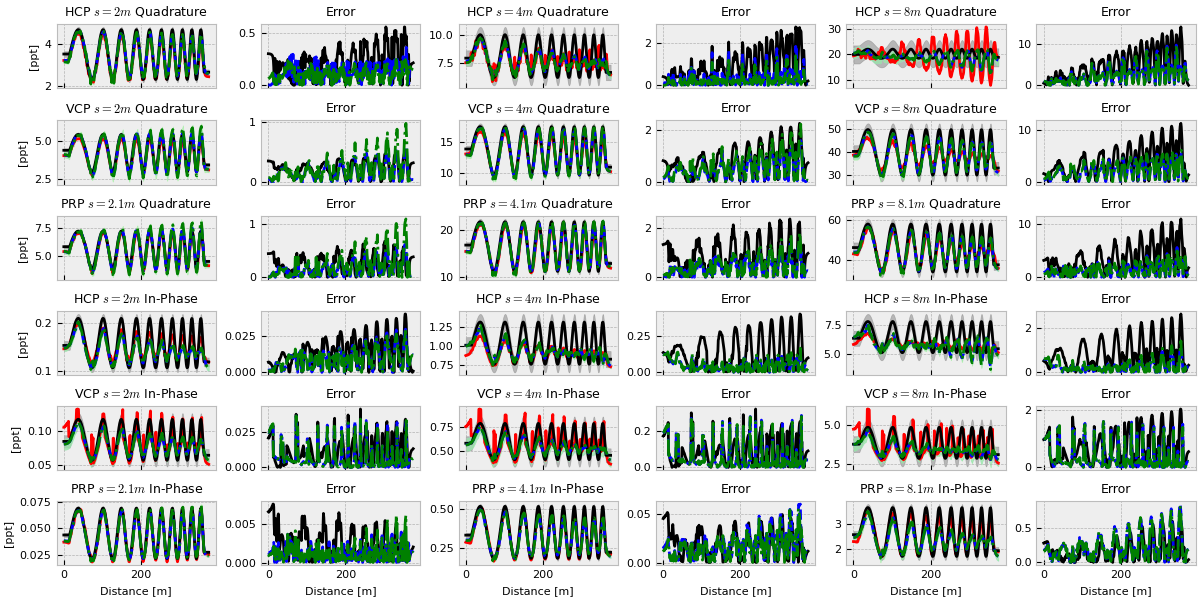

In [29]:
PlotDatas(data_true, data_1D, data_lci, data_pwi)
plt.savefig('figures/datafit_sinu.eps', format='eps', bbox_inches='tight')